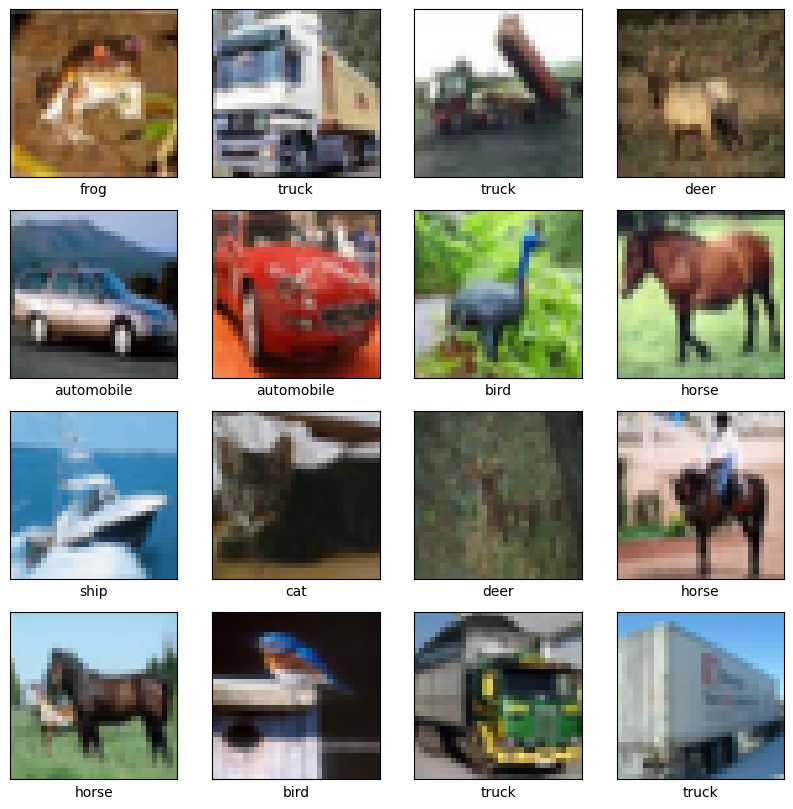

E:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 34ms/step - accuracy: 0.3283 - loss: 1.8175 - val_accuracy: 0.5134 - val_loss: 1.3317
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.5493 - loss: 1.2655 - val_accuracy: 0.5889 - val_loss: 1.1623
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.6177 - loss: 1.0869 - val_accuracy: 0.6435 - val_loss: 1.0100
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.6624 - loss: 0.9685 - val_accuracy: 0.6450 - val_loss: 1.0149
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.6862 - loss: 0.9016 - val_accuracy: 0.6719 - val_loss: 0.9372
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.7088 - loss: 0.8367 - val_accuracy: 0.6828 - val_loss: 0.9013
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.7251 - loss: 0.7897 - val_accuracy: 0.6778 - val_loss: 0.9381
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.7391 - loss: 0.7465 - 

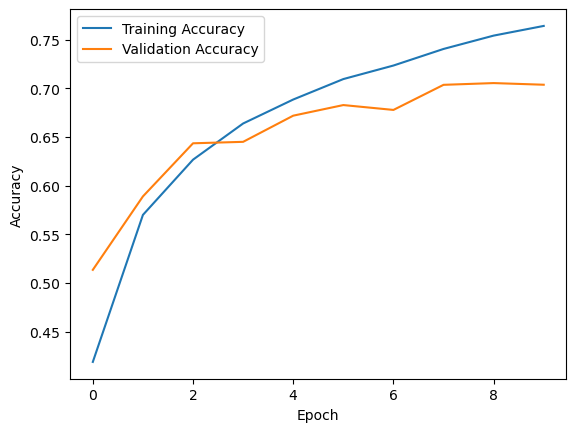

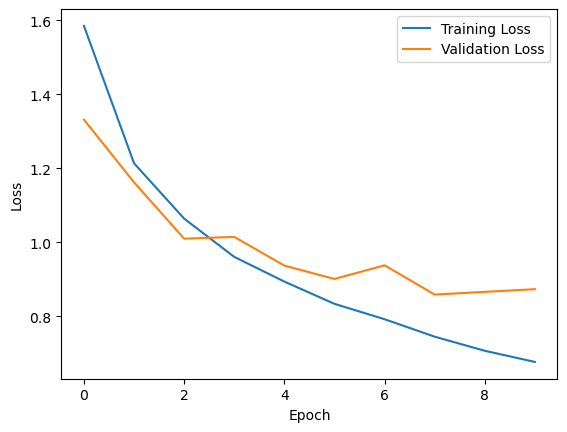

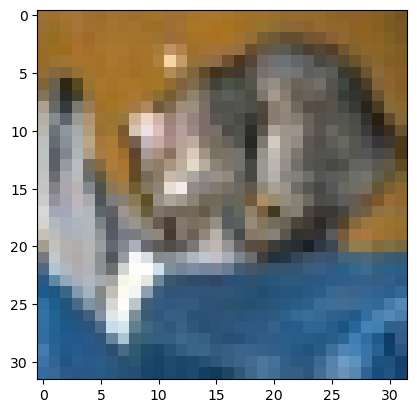

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
Predicted label: cat


In [1]:
# Import Required Libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np

# Load and Preprocess the Dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to between 0 and 1
x_train = x_train / 255.0
x_test = x_test / 255.0

# Convert class vectors to one-hot encoded
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Display Sample Images
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[np.argmax(y_train[i])])
plt.show()

# Build the CNN Model
model = models.Sequential([
    # Convolutional layers
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Model Summary
model.summary()

# Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the Model
history = model.fit(x_train, y_train, epochs=10, 
                    validation_data=(x_test, y_test), batch_size=64)

# Evaluate the Model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc}")

# Visualize Training Results
# Plot Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Save the Model
model.save('cnn_cifar10_model.h5')

# Load and Predict on a Test Image
img = x_test[0]
plt.imshow(img)
plt.show()

# Preprocess the Image for Prediction
img = np.expand_dims(img, axis=0)  # Expand dimensions for batch
predictions = model.predict(img)
print(f"Predicted label: {class_names[np.argmax(predictions)]}")


Coefficients: [  197.84070075 23304.13526176]
Intercept: -19918.517009574396
Mean Squared Error: 192582176.29714066
R-squared: 0.997710081137965


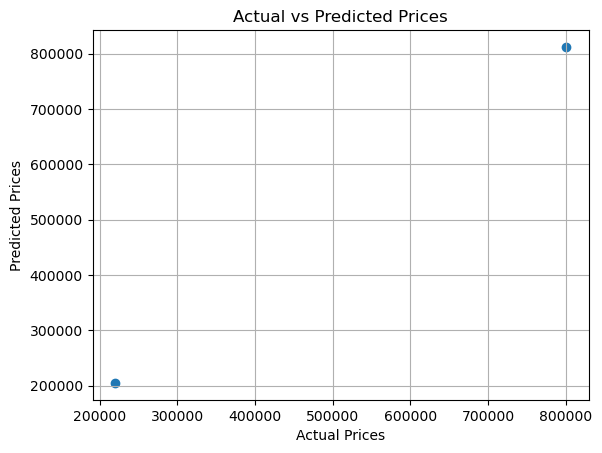

Model saved as 'house_price_model.pkl'
Predicted Price: 690124.2615603993


E:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Synthetic dataset
data = {
    "Size (sq ft)": [850, 900, 1200, 1500, 1800, 2000, 2500, 3000, 3500, 4000],
    "Number of Rooms": [2, 2, 3, 3, 4, 4, 5, 5, 6, 6],
    "Price (USD)": [200000, 220000, 270000, 350000, 420000, 480000, 600000, 700000, 800000, 900000],
}
df = pd.DataFrame(data)

# Split dataset into features (X) and target (y)
X = df[["Size (sq ft)", "Number of Rooms"]]
y = df["Price (USD)"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Display model coefficients
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Mean Squared Error and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Plot actual vs predicted prices
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.show()

# Save the trained model
joblib.dump(model, "house_price_model.pkl")
print("Model saved as 'house_price_model.pkl'")

# Load the model and make a new prediction
loaded_model = joblib.load("house_price_model.pkl")
new_data = np.array([[3000, 5]])  # Example: 3000 sq ft, 5 rooms
new_prediction = loaded_model.predict(new_data)
print(f"Predicted Price: {new_prediction[0]}")


In [3]:
a=55
print(a)

55


In [4]:
type(a)

int

In [6]:
b={1:"Apple", 2:"Mango", 3:"Banana"}
b

{1: 'Apple', 2: 'Mango', 3: 'Banana'}

In [7]:
print(type(b))

<class 'dict'>


In [8]:
print(len(b))

3


In [9]:
type(b)

dict

In [10]:
b.values()

dict_values(['Apple', 'Mango', 'Banana'])

In [11]:
b.keys()

dict_keys([1, 2, 3])

In [12]:
b.items()

dict_items([(1, 'Apple'), (2, 'Mango'), (3, 'Banana')])

In [13]:
b[1]

'Apple'

In [14]:
b[2]

'Mango'

In [15]:
b[3]

'Banana'

In [18]:
print(b[2])

Mango


In [19]:
print(b[3])

Banana


In [20]:
print(b[1])

Apple


In [21]:
# Input a number from the user
number = int(input("Enter a number: "))

# Check if the number is even or odd
if number % 2 == 0:
    print(f"{number} is an even number.")
else:
    print(f"{number} is an odd number.")


Enter a number:  5


5 is an odd number.


In [26]:
number = int(input("Enter a number: "))
if number % 3 == 0:
    print(f"{number} is an even number .")
else:
    print(f"{number} is an odd number. ")

Enter a number:  4


4 is an odd number. 


In [27]:
# Input the marks from the user
marks = int(input("Enter your marks: "))

# Determine the grade based on marks
if marks >= 90:
    print("Grade: A")
elif marks >= 75:
    print("Grade: B")
elif marks >= 50:
    print("Grade: C")
else:
    print("Grade: F")


Enter your marks:  80


Grade: B


In [30]:
marks = int(input("Enter your marks: "))
if marks >= 90:
    print("Grade: A")
elif marks >= 75:
    print("Grade: B")
elif marks >= 50:
    print("Grade: C")
else:
    print("Grade: F")

Enter your marks:  90


Grade: A


In [32]:
# Input age from the user
age = int(input("Enter your age: "))

# Determine age group
if age >= 18:
    if age >= 60:
        print("You are a senior citizen.")
    else:
        print("You are an adult.")
else:
    print("You are a minor.")


Enter your age:  18


You are an adult.


In [35]:
# Input username and password
username = input("Enter username: ")
password = input("Enter password: ")

# Check credentials
if username == "admin" and password == "1234":
    print("Login successful!")
else:
    print("Invalid credentials. Try again.")


Enter username:  admin
Enter password:  1234


Login successful!


In [37]:
username = input("Enter username: ")
password = input("Enter password: ")
if username == "admin" and password == "1234":
    print("Login successful !")
else:
    print("Invalid credentials. Try again.")

Enter username:  admin
Enter password:  1234


Login successful !
